# Aim : to create the file that OLMT can read to create ensembles

In [1]:
pwd


'/Users/ud4/repos/GitHub/FATESFACE/Jupyter_Notebooks'

In [1]:
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!ls -ltr tmp

total 13504
-rw-r--r--@ 1 ud4  ORNL\Domain Users   15061 Sep 18  2024 obs_a.csv
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9835 Sep 18  2024 r20240914e_RD.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9865 Sep 18  2024 r240914e_RD.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9885 Sep 18  2024 r240914d_RD.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9861 Sep 18  2024 r240914c_RD.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9878 Sep 18  2024 r240914b_RD.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9885 Sep 18  2024 r240913_RD.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9870 Sep 18  2024 r240914a_RD.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9864 Sep 19  2024 r240914e_ECA.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9814 Sep 19  2024 r240913_ECA.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9826 Sep 19  2024 r240914a_ECA.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9813 Sep 19  2024 r240914b_ECA.xlsx
-rw-r--r--@ 1 ud4  ORNL\Domain Users    9825 Sep 19  2024 r240914c_ECA.xlsx
-rw-r--r--@ 1 u

In [3]:
!open .

In [32]:
# Load the Excel file
#excel_file = 'tmp/FinalRD_Calibration_Ranges.xlsx'
excel_file = 'tmp/FinalRD_Calibration_Ranges_ORNL2.xlsx'
excel_file = 'tmp/FinalRD_Calibration_Ranges_ORNL.xlsx'
excel_file = 'tmp/RD_nonlog.xlsx'
excel_file = 'tmp/RD_nonlog_revised.xlsx'
excel_file = 'tmp/RD_nonlog_revised2.xlsx'
excel_file = 'tmp/ECA_nonlog_revised3.xlsx'
fn = "RD"
excel_file = f'tmp/{fn}_nonlog_Sc4nRevised.xlsx'

In [33]:
df = pd.read_excel(excel_file)

# Display the data
print(df)

      fates_maintresp_leaf_ryan1991_baserate  \
0                               1.000000e-08   
1                               1.599733e-08   
2                               2.199466e-08   
3                               2.799199e-08   
4                               3.398933e-08   
...                                      ...   
1495                            8.976011e-06   
1496                            8.982008e-06   
1497                            8.988005e-06   
1498                            8.994003e-06   
1499                            9.000000e-06   

      fates_maintresp_nonleaf_baserate  fates_cnp_store_ovrflw_frac  \
0                         1.000000e-07                     0.000000   
1                         1.266177e-07                     0.009340   
2                         1.532355e-07                     0.018679   
3                         1.798532e-07                     0.028019   
4                         2.064710e-07                     0.037358 

In [34]:
df.head()

,fates_maintresp_leaf_ryan1991_baserate,fates_maintresp_nonleaf_baserate,fates_cnp_store_ovrflw_frac,fates_cnp_vmax_nh4
0,1.000000e-08,1.000000e-07,0.000000,1.000000e-10
1,1.599733e-08,1.266177e-07,0.009340,7.670447e-10
2,2.199466e-08,1.532355e-07,0.018679,1.434089e-09
3,2.799199e-08,1.798532e-07,0.028019,2.101134e-09
4,3.398933e-08,2.064710e-07,0.037358,2.768179e-09


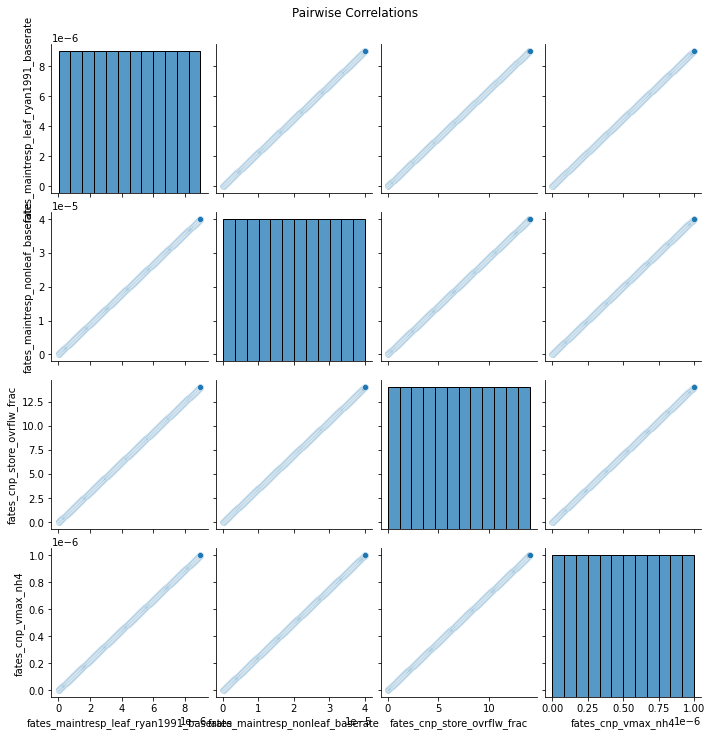

In [35]:
# Create a pair plot
sns.pairplot(df)

# Add a title
plt.suptitle("Pairwise Correlations", y=1.02)

# Save the plot
#plt.savefig("pairwise_correlations.png")

# Show the plot
plt.show()

In [36]:
df.shape[1]

4

In [37]:
Total_samples_needed = 1500
print (Total_samples_needed//df.shape[0])
random_combinations = df.head(0).copy (deep = True)
# Randomizing one col at a time
for i in range(Total_samples_needed//df.shape[0]):
    for idx in range (df.shape[1]):
        df[df.columns[idx]] = df[df.columns[idx]].sample(frac=1).reset_index(drop=True)
    random_combinations = random_combinations.append(df)
random_combinations.reset_index(inplace=True,drop=True)    

1


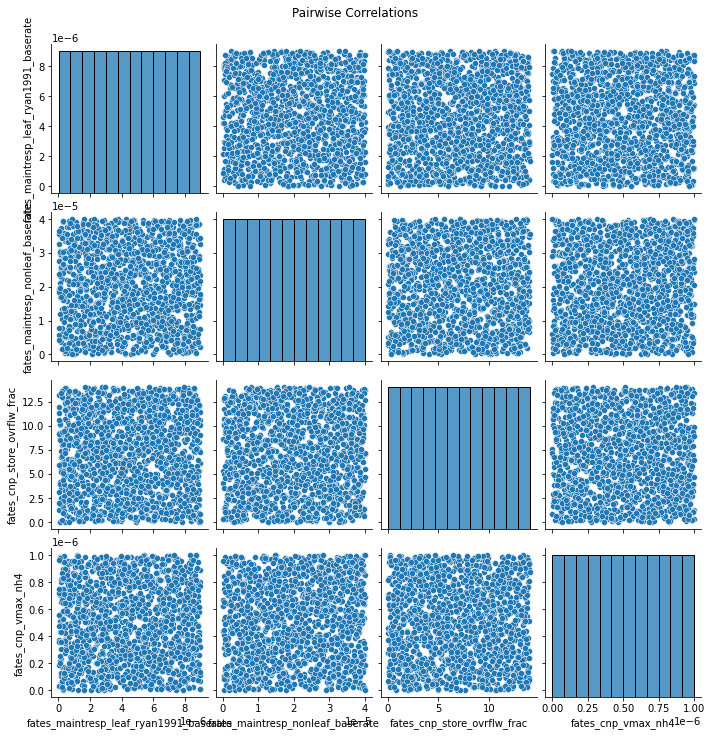

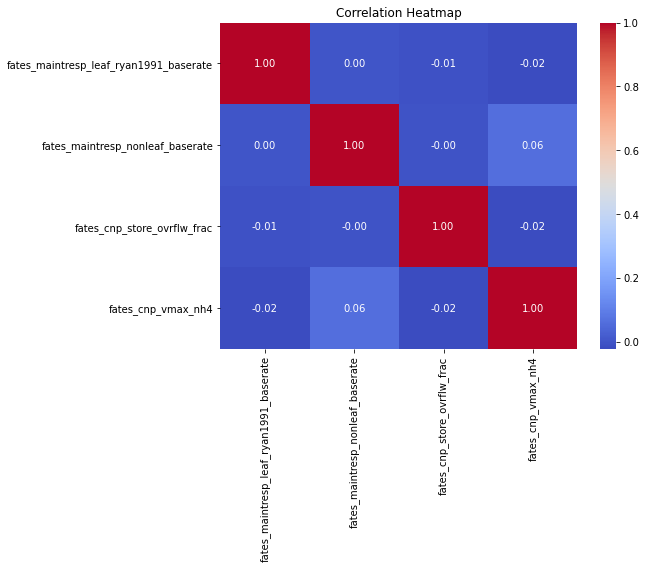

In [38]:
# Create a pair plot
sns.pairplot(random_combinations)

# Add a title
plt.suptitle("Pairwise Correlations", y=1.02)

# Save the plot
#plt.savefig("pairwise_correlations.png")

# Show the plot
plt.show()

# Calculate the correlation matrix
correlation_matrix = random_combinations.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

# Save the heatmap
#plt.savefig("correlation_heatmap.png")

# Show the plot
plt.show()

In [39]:
random_combinations_log = random_combinations.copy(deep=True)
random_combinations_log['log_fates_cnp_vmax_nh4'] = np.log10(random_combinations_log['fates_cnp_vmax_nh4'])
random_combinations_log = random_combinations_log.drop('fates_cnp_vmax_nh4', axis=1)

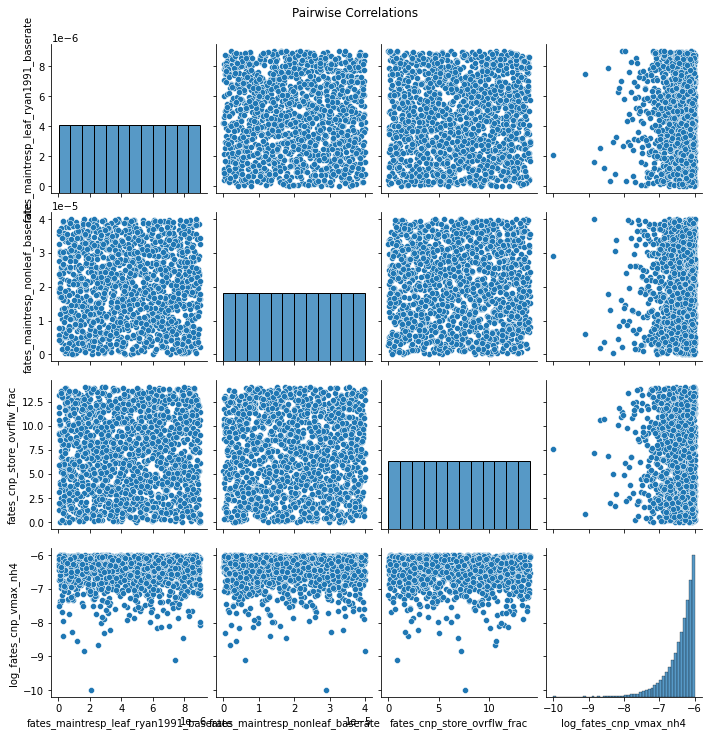

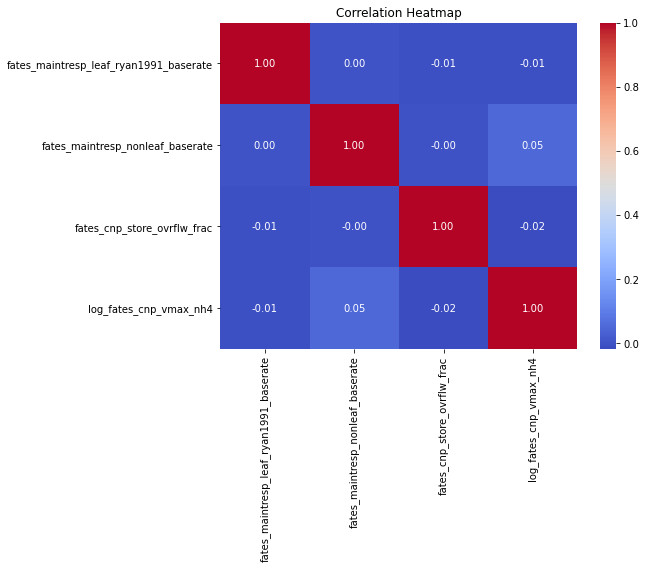

In [40]:
# Create a pair plot
sns.pairplot(random_combinations_log)

# Add a title
plt.suptitle("Pairwise Correlations", y=1.02)

# Save the plot
#plt.savefig("pairwise_correlations.png")

# Show the plot
plt.show()


# Calculate the correlation matrix
correlation_matrix = random_combinations_log.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

# Save the heatmap
#plt.savefig("correlation_heatmap.png")

# Show the plot
plt.show()

In [41]:
random_combinations

,fates_maintresp_leaf_ryan1991_baserate,fates_maintresp_nonleaf_baserate,fates_cnp_store_ovrflw_frac,fates_cnp_vmax_nh4
0,0.000005,0.000034,0.028019,8.225661e-07
1,0.000001,0.000007,8.461641,9.815557e-08
2,0.000008,0.000033,4.893929,4.490211e-07
3,0.000008,0.000019,9.376918,1.681953e-07
4,0.000007,0.000032,1.288859,2.075509e-07
...,...,...,...,...
1495,0.000004,0.000019,13.318212,1.855384e-07
1496,0.000007,0.000036,6.715143,6.858219e-07
1497,0.000007,0.000030,11.114076,5.964380e-07
1498,0.000009,0.000011,12.104069,6.191175e-07


In [42]:
df_comb = pd.DataFrame(random_combinations, columns=df.columns)
df_comb["fates_cnp_vmax_no3"] = df_comb["fates_cnp_vmax_nh4"]
df_comb["fates_cnp_vmax_p"] = df_comb["fates_cnp_vmax_nh4"]/10

In [43]:
#df_comb.to_csv(f'tmp/combinations_RD_4.csv', index=False)
#df_comb.to_csv(f'tmp/combinations_RD_4', sep= ' ',  index=False,header=False )

#df_comb.to_csv(f'tmp/combinations_RD_revised2', sep= ' ',  index=False,header=False ) # non-log transform
#df_comb.to_csv(f'tmp/combinations_RD_revised2.csv', sep= ',',  index=False,header=False ) # non-log transform

#ECA
#df_comb.to_csv(f'tmp/combinations_ECA_revised3', sep= ' ',  index=False,header=False ) # non-log transform
#df_comb.to_csv(f'tmp/combinations_ECA_revised3.csv', sep= ',',  index=False,header=False ) # non-log transform

In [44]:
#ECA
df_comb.to_csv(f'tmp/combinations_{fn}_Sc4nRevised', sep= ' ',  index=False,header=False ) # non-log transform
df_comb.to_csv(f'tmp/combinations_{fn}_Sc4nRevised.csv', sep= ',',  index=False,header=False ) # non-log transform


In [45]:
df_comb

,fates_maintresp_leaf_ryan1991_baserate,fates_maintresp_nonleaf_baserate,fates_cnp_store_ovrflw_frac,fates_cnp_vmax_nh4,fates_cnp_vmax_no3,fates_cnp_vmax_p
0,0.000005,0.000034,0.028019,8.225661e-07,8.225661e-07,8.225661e-08
1,0.000001,0.000007,8.461641,9.815557e-08,9.815557e-08,9.815557e-09
2,0.000008,0.000033,4.893929,4.490211e-07,4.490211e-07,4.490211e-08
3,0.000008,0.000019,9.376918,1.681953e-07,1.681953e-07,1.681953e-08
4,0.000007,0.000032,1.288859,2.075509e-07,2.075509e-07,2.075509e-08
...,...,...,...,...,...,...
1495,0.000004,0.000019,13.318212,1.855384e-07,1.855384e-07,1.855384e-08
1496,0.000007,0.000036,6.715143,6.858219e-07,6.858219e-07,6.858219e-08
1497,0.000007,0.000030,11.114076,5.964380e-07,5.964380e-07,5.964380e-08
1498,0.000009,0.000011,12.104069,6.191175e-07,6.191175e-07,6.191175e-08


In [46]:
random_combinations.min()

fates_maintresp_leaf_ryan1991_baserate    1.000000e-08
fates_maintresp_nonleaf_baserate          1.000000e-07
fates_cnp_store_ovrflw_frac               0.000000e+00
fates_cnp_vmax_nh4                        1.000000e-10
dtype: float64

In [47]:
random_combinations.max()

fates_maintresp_leaf_ryan1991_baserate    9.000000e-06
fates_maintresp_nonleaf_baserate          4.000000e-05
fates_cnp_store_ovrflw_frac               1.400000e+01
fates_cnp_vmax_nh4                        1.000000e-06
dtype: float64